# Synthetic dataset

## Data Extraction

In [2]:
import pandas as pd

In [9]:
real_shap_30 = pd.read_csv("../dp_cgans/resources/shap_30_important_features_icu_dka_dataset.csv")
# real_shap_30 = real_shap_30.drop("lactate_max", axis=1)
syn_data_baseline = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_baseline.csv")
syn_data_baseline= syn_data_baseline.drop(syn_data_baseline.columns[0], axis=1)
# to fix: hyperparameters and missing parameter
syn_data = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_e1000_bs750_xaiSHAP_beta0_13-11T00.04.49.csv")
syn_data = syn_data.drop(syn_data.columns[0], axis=1)
syn_data_shap = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_015.csv")
syn_data_shap = syn_data_shap.drop(syn_data_shap.columns[0], axis=1)



# Chang synthetic datasets to have the same columns as real dataset
ch_syn_1 = pd.read_csv("../dp_cgans/tests/results/2025_09_18_12_46_41_dpcgans_1571_rows_icu_dka.csv")
ch_syn_2 = pd.read_csv("../dp_cgans/tests/results/2025_09_18_14_56_11_dpcgans_1571_rows_icu_dka.csv")

## Datasets Structure and Size

### Real dataset: 30 features according with feature importances of SHAP + outcome (in_hospital_death)
1571 patients
#### - syn_data: Synthetic data without shap penalty
#### - syn_data_shap: Synthetic data with 0.15 * shap penalty

In [ ]:
real_shap_30 = pd.read_csv("../dp_cgans/resources/shap_30_icu_dka_dataset.csv")
syn_data = pd.read_csv("../dp_cgans/tests/output/2025_12_03_16_37_07_syn_data_shap_baseline_new.csv").iloc[:, 1:]
syn_data_10 = pd.read_csv("../dp_cgans/tests/output/2025_12_03_17_07_29_syn_data_shap_10_new.csv").iloc[:, 1:]
syn_data_5 = pd.read_csv("../dp_cgans/tests/output/2025_12_03_17_40_55_syn_data_shap_5_new.csv").iloc[:, 1:]

In [37]:
real_shap_30.info()
syn_data.info()
syn_data_10.info()
syn_data_5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bun_max             1567 non-null   float64
 1   urineoutput         1539 non-null   float64
 2   wbc_min             1552 non-null   float64
 3   bicarbonate_max     1567 non-null   float64
 4   anion_gap_initial   1567 non-null   float64
 5   weight              1542 non-null   float64
 6   lactate_max         1157 non-null   float64
 7   ph_min              1236 non-null   float64
 8   glucose_max         1567 non-null   float64
 9   age                 1571 non-null   int64  
 10  wbc_max             1552 non-null   float64
 11  glucose_min         1567 non-null   float64
 12  heart_rate_initial  1571 non-null   float64
 13  osmolality_max      1567 non-null   float64
 14  calcium_max         1558 non-null   float64
 15  sofa                1571 non-null   int64  
 16  resp_r

In [27]:
print("Real:", )
real_shap_30.describe(include='all')


Real:


,bun_max,urineoutput,wbc_min,bicarbonate_max,anion_gap_initial,weight,lactate_max,ph_min,glucose_max,age,...,ph_max,wbc_initial,calcium_initial,platelet_initial,mbp_max,los,resp_rate_initial,potassium_min,bun_min,in_hospital_death
count,1567.000000,1539.000000,1552.000000,1567.000000,1567.000000,1542.000000,1157.000000,1236.000000,1567.000000,1571.000000,...,1236.000000,1552.000000,1558.000000,1553.000000,1570.000000,1571.000000,1570.000000,1567.000000,1567.000000,1571.000000
mean,34.279515,2220.870370,7.618557,25.287173,19.301851,79.243709,3.060933,7.270356,375.851308,51.938892,...,7.404765,12.077062,8.497433,246.562138,105.490340,2.842729,20.099363,3.525207,16.876197,0.052833
std,27.877487,1658.747896,3.798653,4.286125,6.551799,22.383403,3.004555,0.118249,222.224178,17.972239,...,0.080464,6.509646,0.994736,114.981633,23.474229,4.316703,6.368967,0.497294,16.340134,0.223770
min,2.000000,0.000000,0.100000,8.000000,3.000000,7.000000,0.600000,6.820000,35.000000,18.000000,...,7.030000,0.100000,3.100000,10.000000,36.000000,0.002269,0.000000,1.500000,1.000000,0.000000
25%,15.000000,1050.000000,5.100000,23.000000,15.000000,64.100000,1.400000,7.210000,258.000000,38.000000,...,7.360000,7.475000,7.900000,178.000000,92.000000,1.038623,16.000000,3.200000,6.000000,0.000000
50%,25.000000,1875.000000,6.800000,25.000000,19.000000,75.000000,2.100000,7.290000,321.000000,53.000000,...,7.410000,10.700000,8.500000,230.000000,102.000000,1.730012,19.000000,3.500000,11.000000,0.000000
75%,45.000000,2942.500000,9.100000,28.000000,23.000000,90.650000,3.500000,7.350000,424.000000,65.000000,...,7.460000,15.025000,9.000000,294.000000,114.000000,2.827859,23.000000,3.800000,21.000000,0.000000
max,203.000000,15985.000000,30.800000,44.000000,45.000000,195.000000,27.000000,7.500000,3090.000000,98.000000,...,7.700000,47.000000,15.000000,1558.000000,297.000000,56.978252,63.000000,7.100000,129.000000,1.000000


In [32]:
print("Synthetic without SHAP penalty:")
syn_data.describe(include='all')


Synthetic without SHAP penalty:


,bun_max,urineoutput,wbc_min,bicarbonate_max,anion_gap_initial,weight,lactate_max,ph_min,glucose_max,age,...,ph_max,wbc_initial,calcium_initial,platelet_initial,mbp_max,los,resp_rate_initial,potassium_min,bun_min,in_hospital_death
count,1569.000000,1540.000000,1553.000000,1568.000000,1565.000000,1542.000000,1130.000000,1241.000000,1568.000000,1571.000000,...,1211.000000,1559.000000,1557.000000,1551.000000,1571.000000,1571.000000,1570.000000,1568.000000,1566.000000,1571.000000
mean,44.391359,3090.394825,9.329047,25.454422,19.960997,85.217953,5.787742,7.266282,584.479777,52.854233,...,7.399282,14.373296,8.635479,327.205485,125.562888,7.528839,21.801223,3.532983,24.120488,0.229153
std,38.721435,3204.323690,6.292629,6.543186,8.547358,34.991805,6.462488,0.139232,555.618440,25.965651,...,0.121340,10.035117,2.345229,273.279428,56.671271,12.122787,11.218667,0.772971,25.618691,0.420422
min,-9.661920,-3852.489110,-2.381092,4.185872,1.118685,-8.614327,-4.365571,6.760808,-720.773657,-9.000000,...,6.865531,-6.781693,-2.989611,-390.543177,-49.072060,-17.653464,-24.257147,1.081420,-22.033304,0.000000
25%,16.768994,992.112387,5.027924,21.131759,14.370989,62.834563,2.092410,7.214333,270.706232,34.000000,...,7.343465,7.156832,7.586065,167.032195,94.668488,1.294005,15.189601,2.986805,7.187625,0.000000
50%,31.642350,2094.957780,7.909480,25.556735,18.960736,80.714601,3.619671,7.272247,394.430781,54.000000,...,7.404126,11.781579,8.586986,263.580010,110.251329,2.523721,20.270394,3.500937,15.020711,0.000000
75%,60.456529,4073.668171,11.945847,29.642123,24.009936,101.147023,6.935436,7.347161,691.986392,73.000000,...,7.461980,19.943428,9.559429,384.810707,134.811454,7.767758,26.260226,4.018895,31.611964,0.000000
max,199.614975,20483.783275,35.509969,49.036825,49.330447,218.872166,36.260163,7.568912,3553.961296,115.000000,...,7.823085,54.727724,19.928074,1751.400836,423.884777,73.105376,71.833763,6.481768,136.502176,1.000000


In [38]:
print("Synthetic with SHAP penalty:")
syn_data_10.describe(include='all')

Synthetic with SHAP penalty:


,bun_max,urineoutput,wbc_min,bicarbonate_max,anion_gap_initial,weight,lactate_max,ph_min,glucose_max,age,...,ph_max,wbc_initial,calcium_initial,platelet_initial,mbp_max,los,resp_rate_initial,potassium_min,bun_min,in_hospital_death
count,1569.000000,1540.000000,1553.000000,1568.000000,1565.000000,1542.000000,1130.000000,1241.000000,1568.000000,1571.000000,...,1211.000000,1559.000000,1557.000000,1551.000000,1571.000000,1571.000000,1570.000000,1568.000000,1566.000000,1571.000000
mean,43.069738,3092.647804,9.412452,25.306375,19.796934,85.237434,5.598776,7.250570,582.716049,52.329090,...,7.396197,14.002182,8.621172,335.403924,123.580545,8.151029,21.676008,3.552937,24.334170,0.212603
std,36.707540,3315.560311,6.060355,6.688880,8.743670,34.345287,6.268709,0.144473,574.828530,26.072032,...,0.128208,9.147434,2.420297,276.378369,60.212378,13.306417,13.053985,0.789993,26.913749,0.409280
min,-19.339640,-3874.282400,-0.840761,4.093602,-0.667845,-22.474609,-7.435370,6.770595,-825.389700,-12.000000,...,6.894568,-2.966777,-1.281223,-374.225730,-52.132714,-22.090128,-22.682315,1.000765,-26.270572,0.000000
25%,16.266785,980.849486,5.359771,20.805078,13.982759,62.158595,2.077284,7.198085,264.290150,32.000000,...,7.337409,7.406777,7.521648,173.505539,90.853189,1.222268,13.827158,3.003329,7.467052,0.000000
50%,31.581491,2101.582794,7.921837,25.179058,18.709852,81.138856,3.438261,7.270703,395.536750,52.000000,...,7.404336,11.901176,8.568089,265.446778,107.349810,2.598424,19.825641,3.515128,14.575777,0.000000
75%,57.992740,4148.493330,11.594235,29.656824,23.754812,103.176871,6.487524,7.328071,690.813945,72.000000,...,7.460586,19.110635,9.590363,386.316683,131.374717,8.401812,27.131760,4.004694,31.760325,0.000000
max,199.482367,18314.765979,35.471999,48.536401,51.632949,239.070424,36.487503,7.568858,3736.177667,115.000000,...,7.783988,51.803640,19.255043,1723.300399,419.257325,75.970680,75.064109,6.387278,149.052505,1.000000


### Missing Values
The missing values of enrolled individuals in MIMIC-IV were all filled with multiple imputations by chained equations (MICE) before the data splitting, separately.



In [11]:
def get_missing_values(data, missing_percentage=0):
    pc_missing = data.isnull().mean() * 100
    pc_missing = pc_missing[pc_missing > missing_percentage].sort_values(ascending=False)
    num_missing = data.isnull().sum()
    num_missing = num_missing[num_missing > (missing_percentage/100)*len(data)].sort_values(ascending=False)
    return pd.DataFrame({'Percentage Missing': pc_missing, 'Number Missing': num_missing})


In [39]:
# Missing values
print("Real missing values:\n", get_missing_values(real_shap_30))
print("Synthetic missing values:\n", get_missing_values(syn_data))
print("Synthetic 10 missing values:\n", get_missing_values(syn_data_10))
print("Synthetic 5 missing values:\n", get_missing_values(syn_data_5))

Real missing values:
                    Percentage Missing  Number Missing
lactate_max                 26.352642             414
ph_min                      21.323997             335
ph_max                      21.323997             335
urineoutput                  2.036919              32
weight                       1.845958              29
wbc_min                      1.209421              19
wbc_max                      1.209421              19
wbc_initial                  1.209421              19
platelet_initial             1.145767              18
calcium_max                  0.827498              13
calcium_initial              0.827498              13
bun_initial                  0.254615               4
potassium_min                0.254615               4
anion_gap_min                0.254615               4
bun_max                      0.254615               4
glucose_initial              0.254615               4
osmolality_max               0.254615               4
glucos

## Overview

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style="whitegrid")

In [20]:

# Histograms for numerical features
def plot_numerical_distributions(df, numeric_vars):
    df[numeric_vars].hist(figsize=(18, 12), bins=30, edgecolor='black')
    plt.suptitle("Distributions of Numerical Variables", fontsize=16)
    plt.tight_layout()
    plt.show()

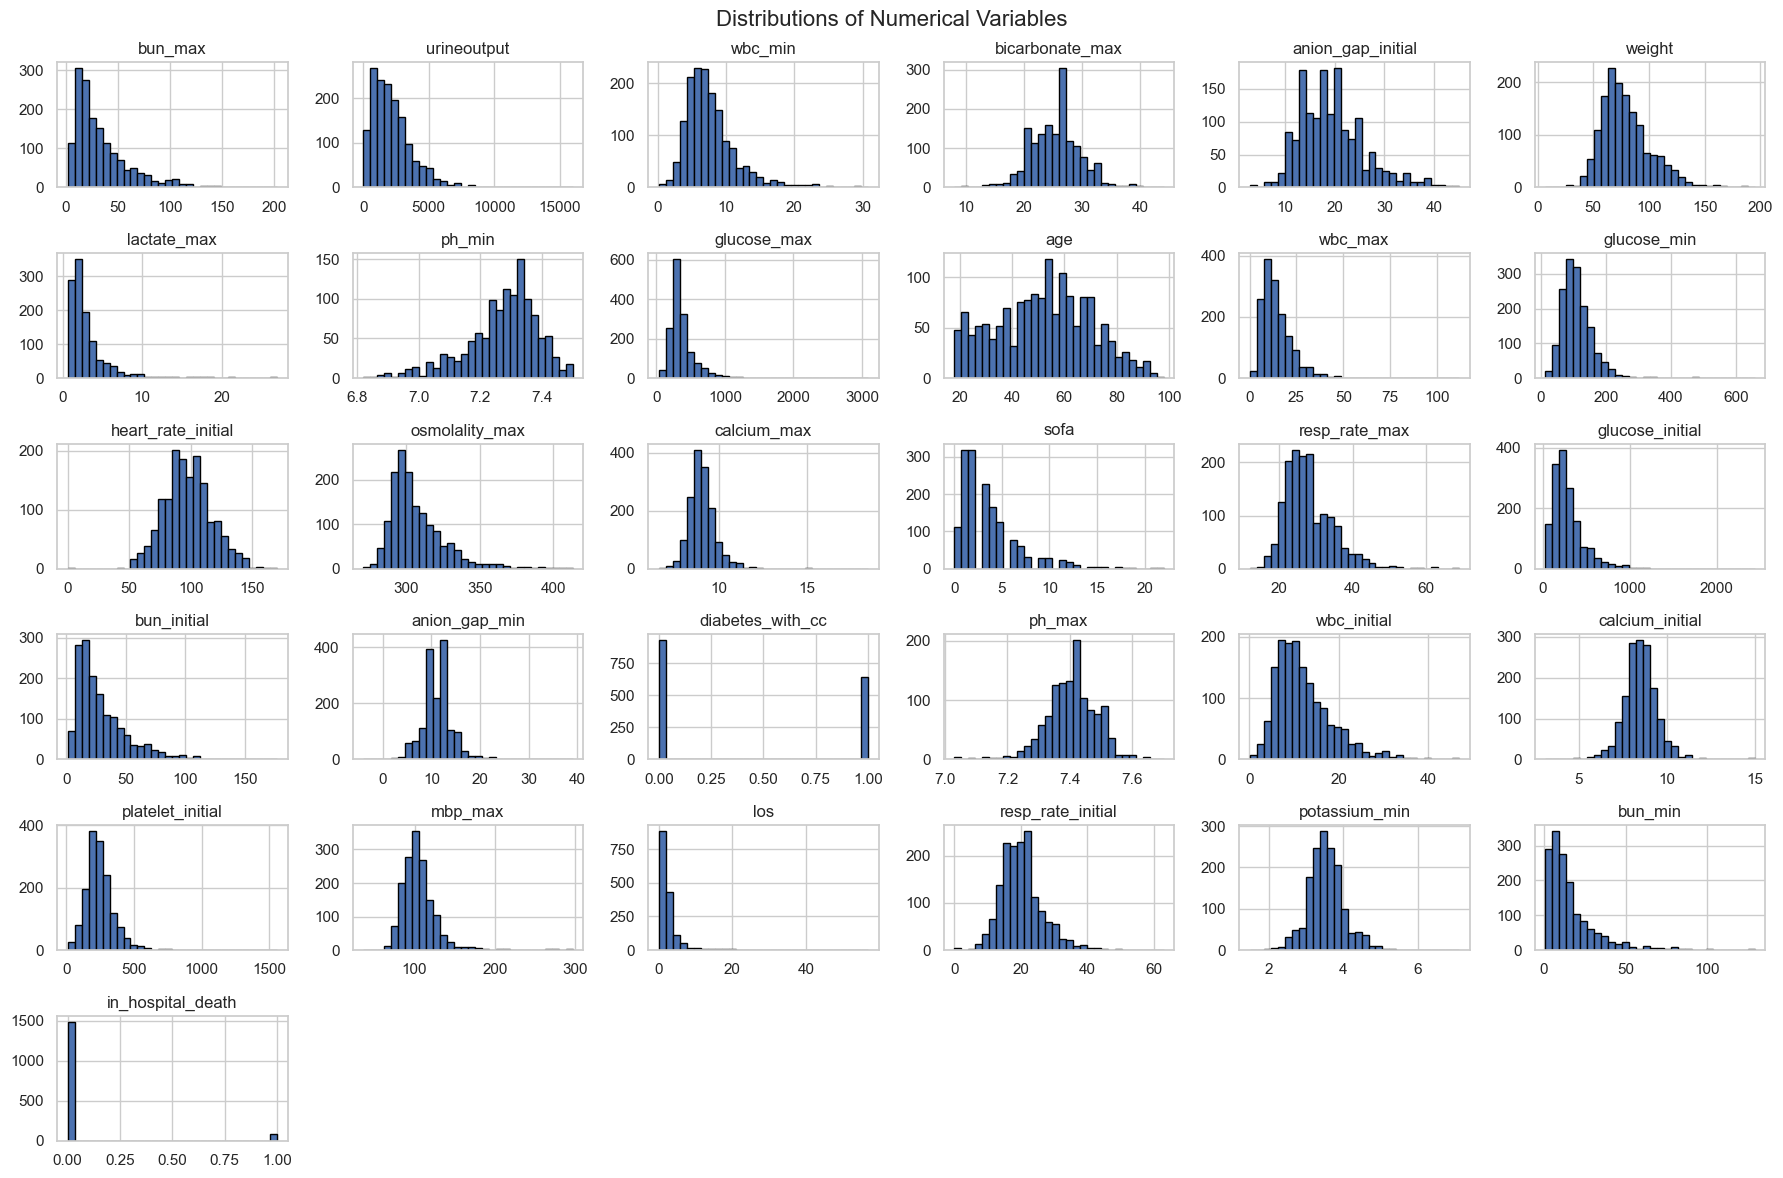

In [29]:
numeric_vars = real_shap_30.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(real_shap_30, numeric_vars)

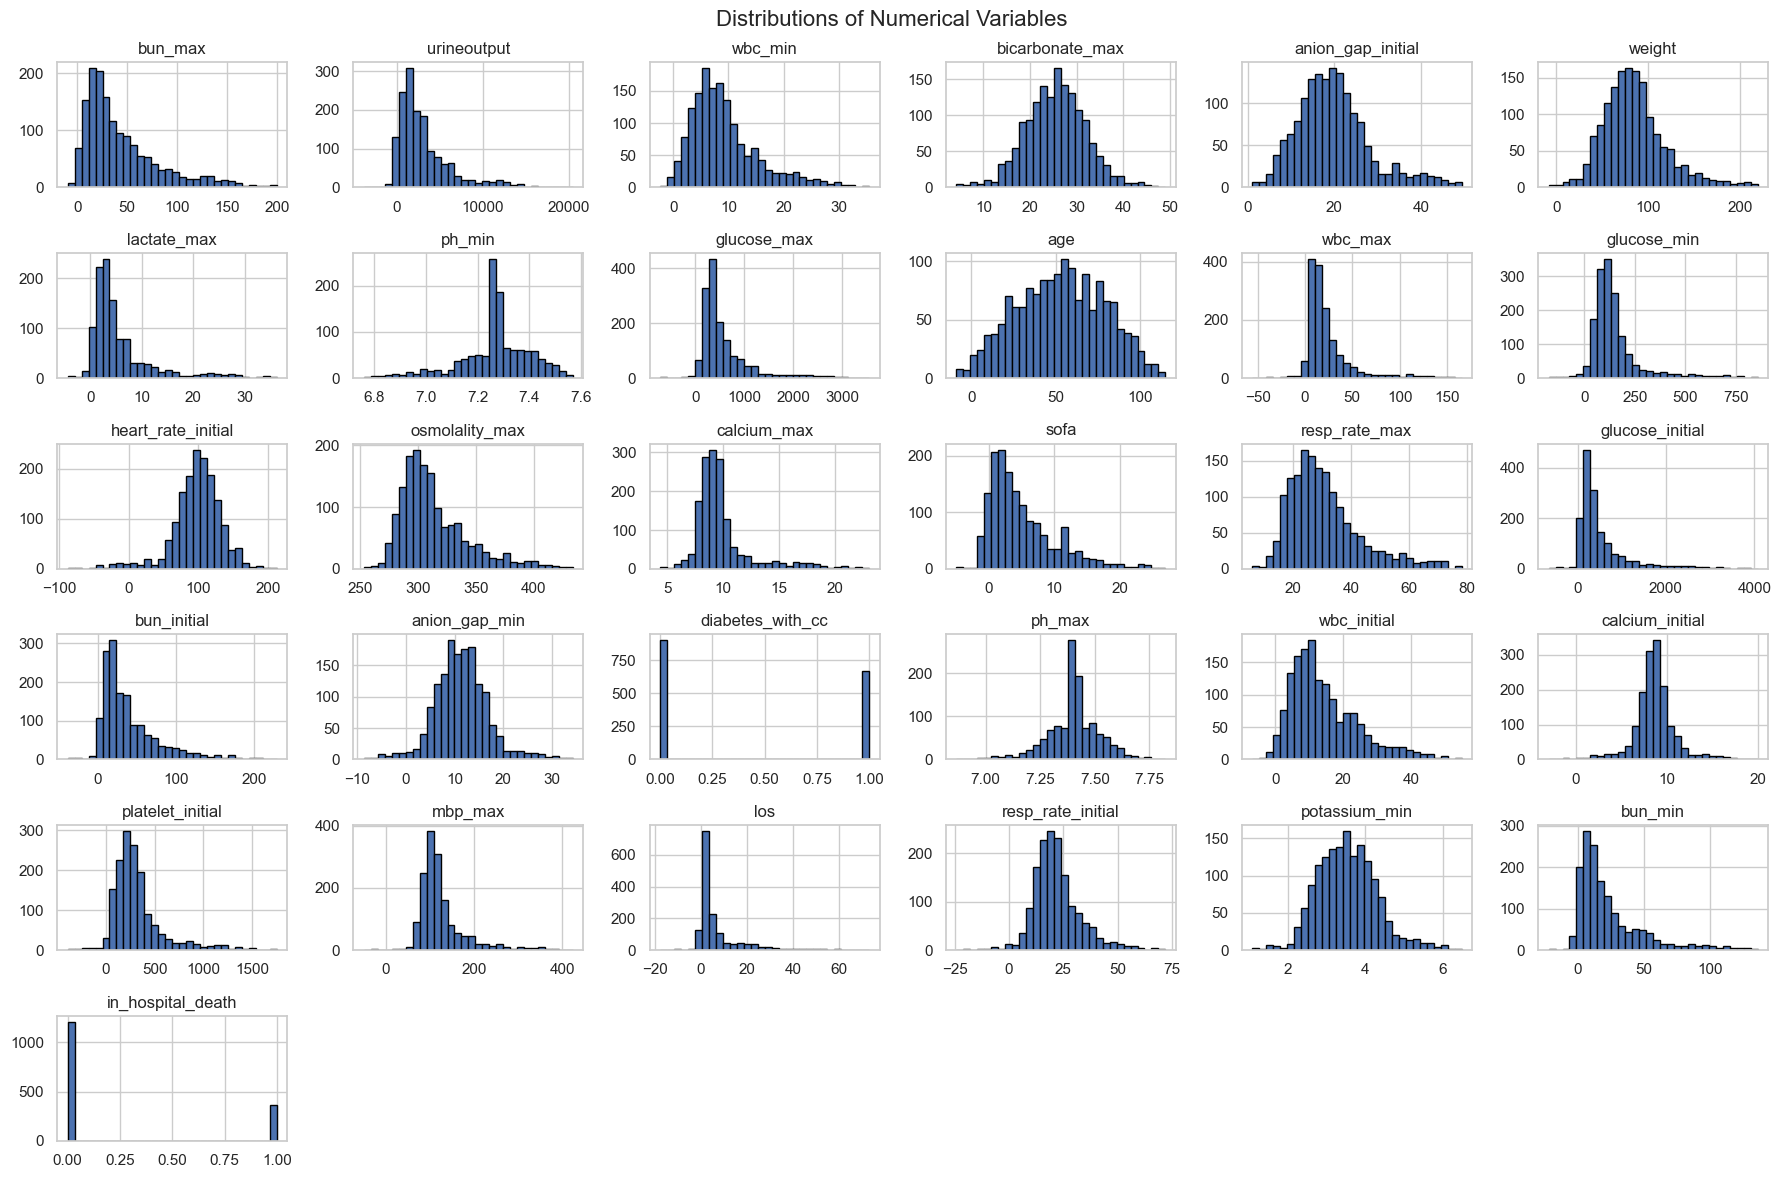

In [34]:
numeric_vars = syn_data.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(syn_data, numeric_vars)

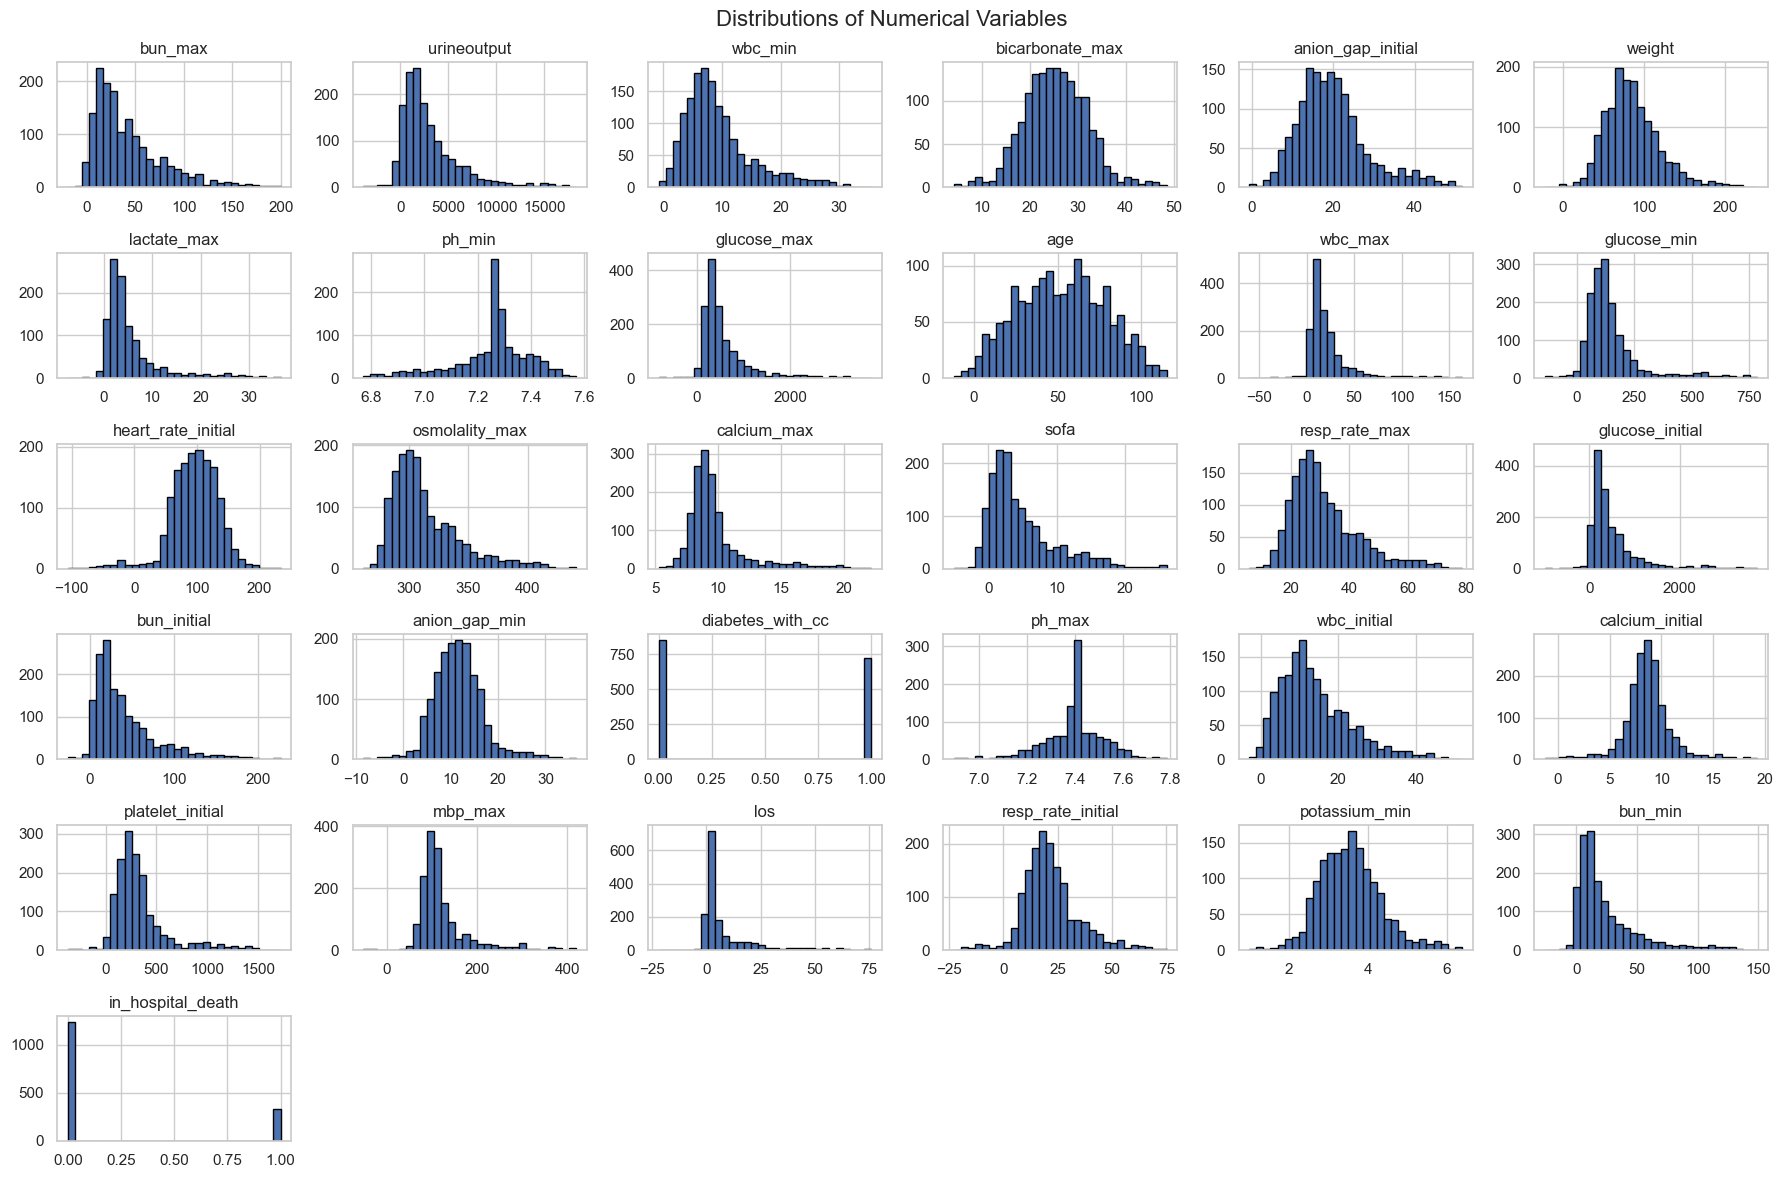

In [40]:
numeric_vars = syn_data_10.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(syn_data_10, numeric_vars)

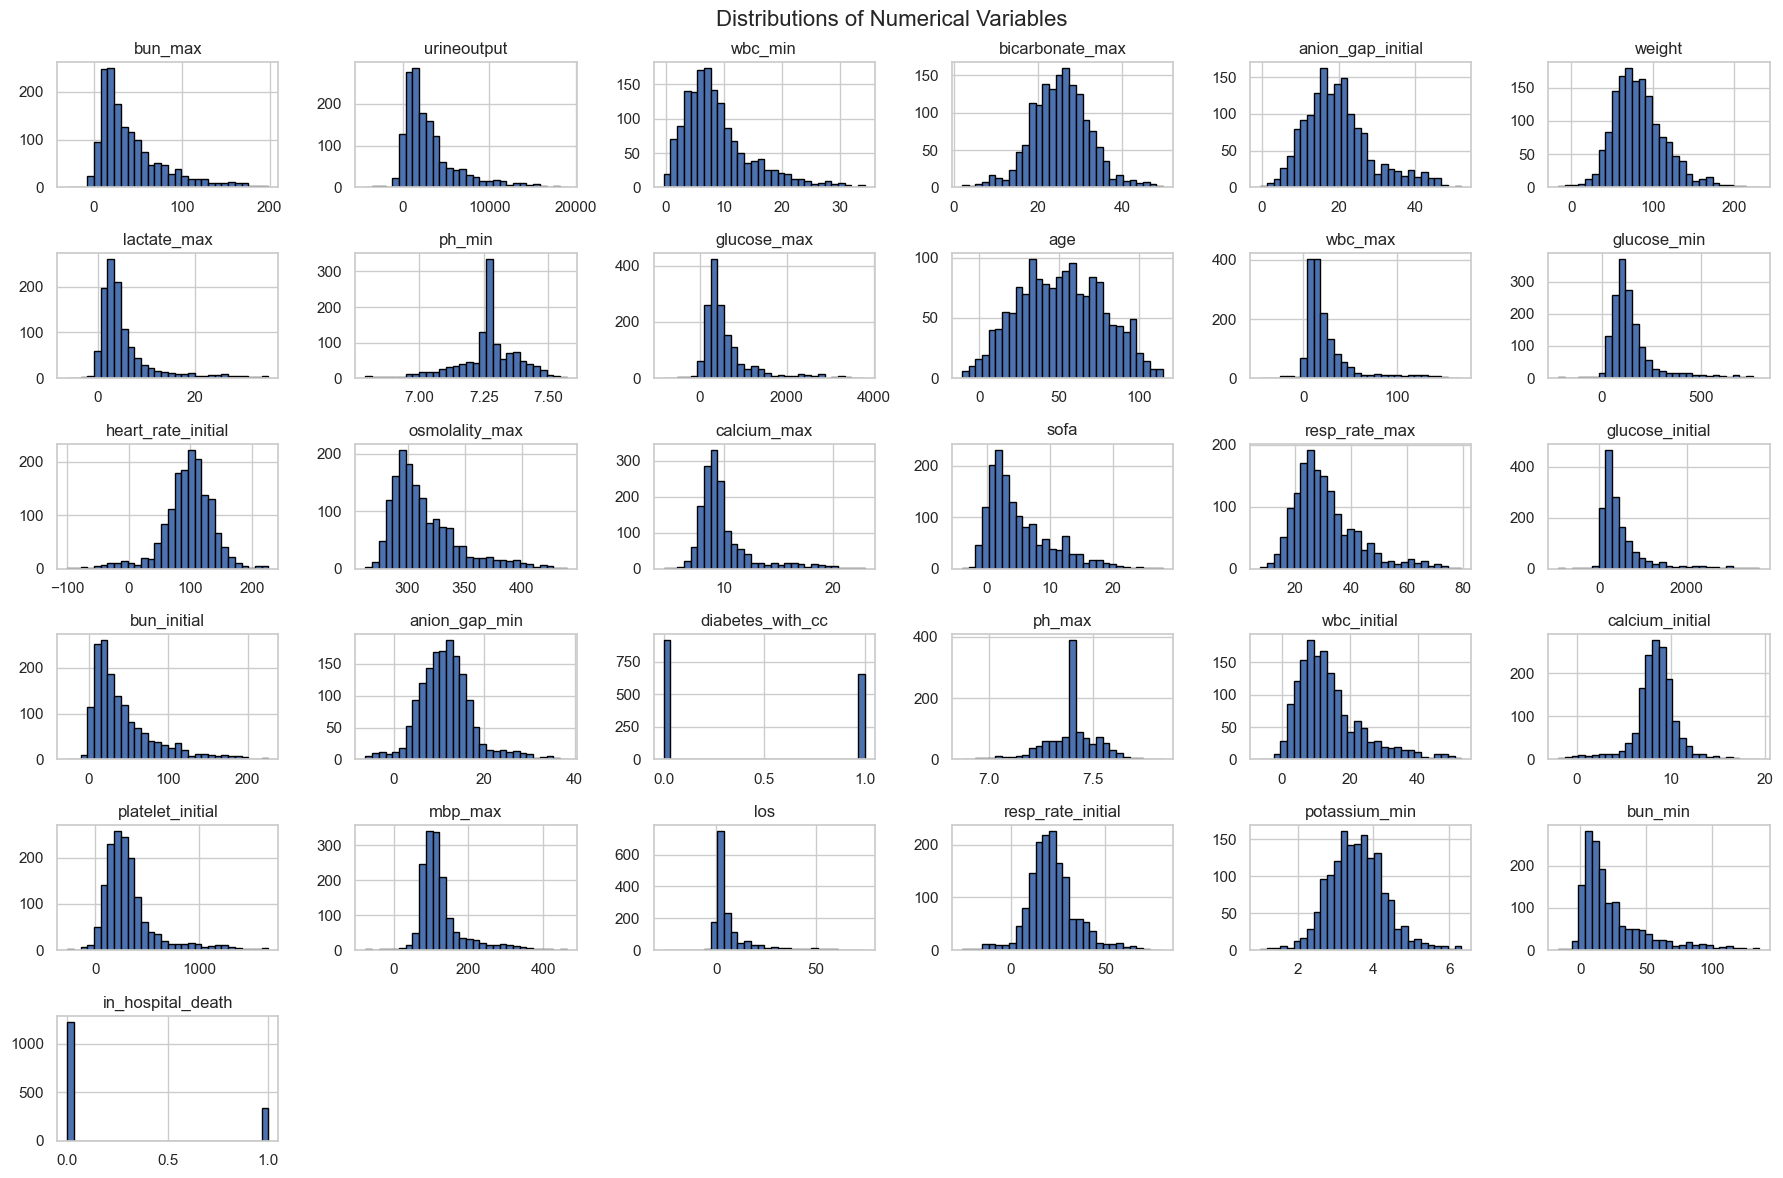

In [41]:
numeric_vars = syn_data_5.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(syn_data_5, numeric_vars)

In [23]:
def compare_correlation_maps(df_list, names, numeric_vars):

    fig, axes = plt.subplots(2, len(df_list), figsize=(7 * len(df_list), 18))

    # ---------- ROW 1: FULL CORRELATION HEATMAPS ----------
    for i, (df, name) in enumerate(zip(df_list, names)):
        corr = df[numeric_vars].corr()

        sns.heatmap(
            corr, 
            cmap='coolwarm', 
            annot=False, 
            fmt=".2f", 
            square=True, 
            ax=axes[0, i], 
            cbar=(i == len(df_list)-1)
        )
        axes[0, i].set_title(f"Correlation Heatmap\n{name}")

    # ---------- ROW 2: CORRELATION WITH OUTCOME ----------
    for i, (df, name) in enumerate(zip(df_list, names)):
        corr = df.corr(numeric_only=True)
        corr_with_y = corr[['in_hospital_death']]

        # 2) Reindex rows using the REAL ordering
        order = corr_with_y['in_hospital_death'].abs().sort_values(ascending=True).index
        corr_with_y = corr_with_y.reindex(order)

        sns.heatmap(
            corr_with_y,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            ax=axes[1, i],
            cbar=(i == len(df_list)-1)
        )

        axes[1, i].set_title(f"Correlation with in_hospital_death\n{name}", fontsize=14)
        axes[1, i].set_yticks(range(len(corr_with_y.index)))
        axes[1, i].set_yticklabels(corr_with_y.index, fontsize=10)
        axes[1, i].set_xticklabels(["in_hospital_death"], fontsize=10)

    plt.tight_layout()
    plt.show()


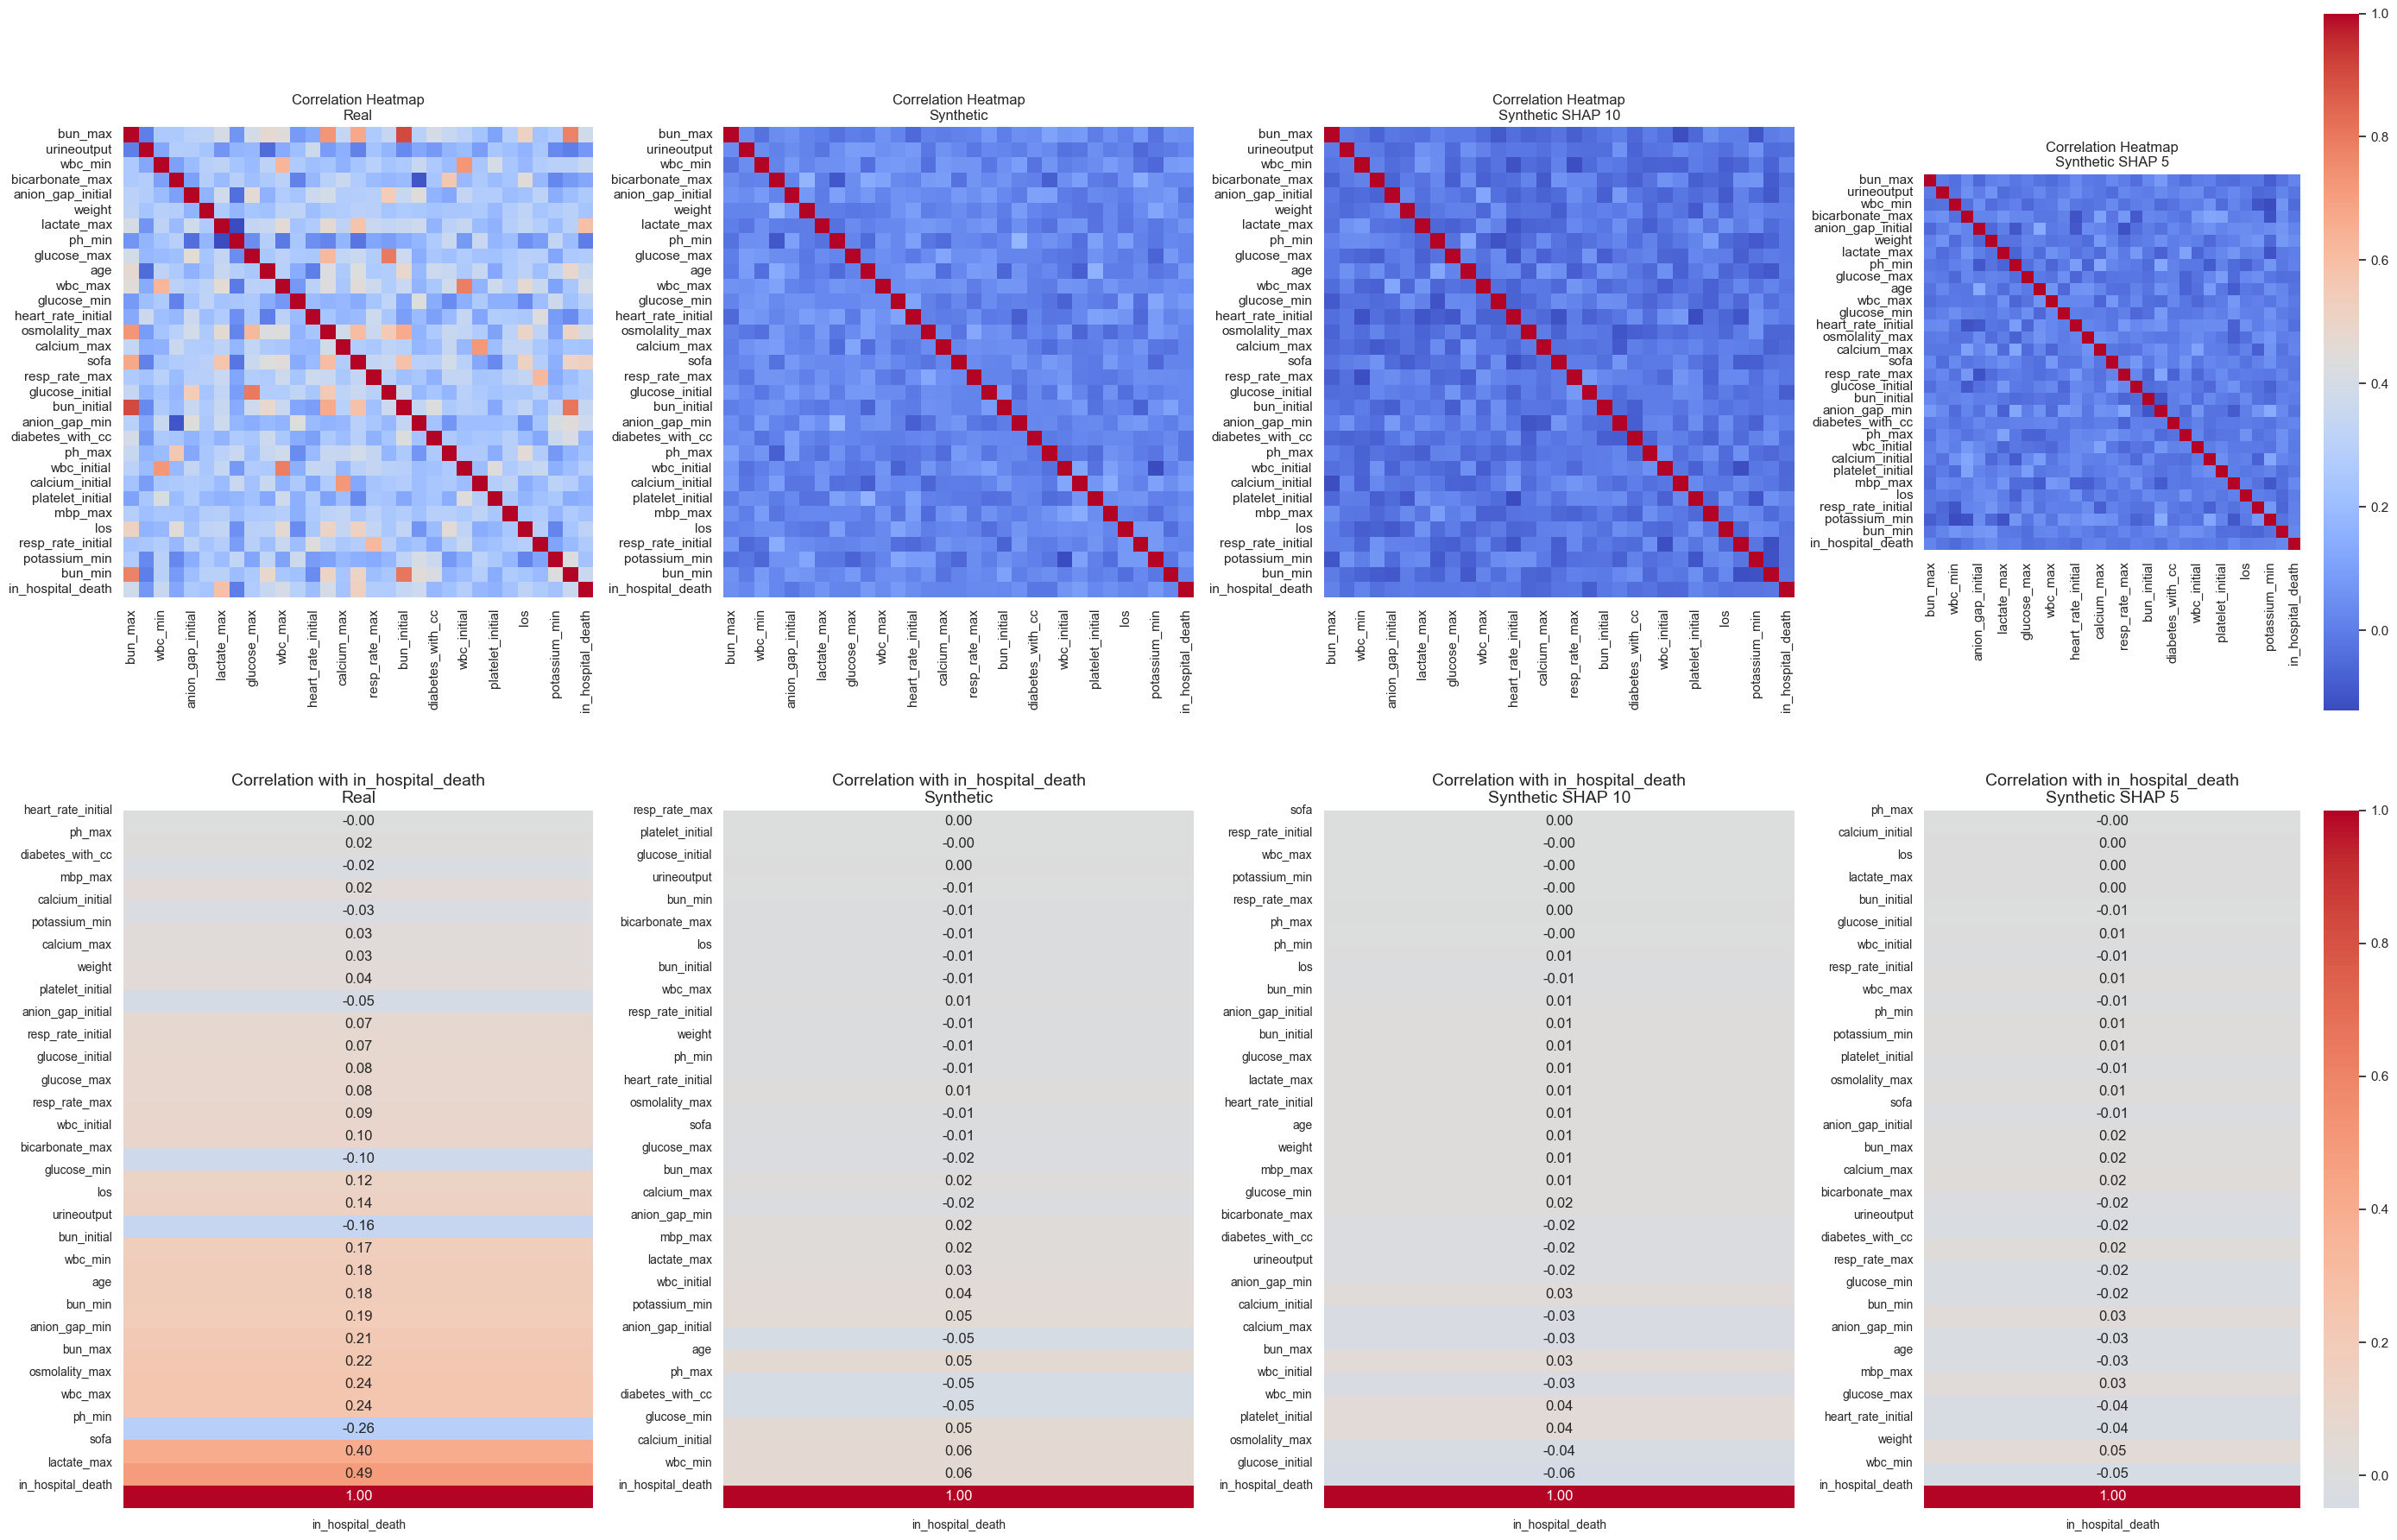

In [42]:
df_list = [real_shap_30, syn_data, syn_data_10, syn_data_5]
names = ["Real", "Synthetic", "Synthetic SHAP 10", "Synthetic SHAP 5"]

compare_correlation_maps(df_list, names, numeric_vars)


## Exploratory Data Analysis


In [43]:
def compare_histograms(df_list, names, column, bins=20):
    n = len(df_list)

    plt.figure(figsize=(6 * n, 5))  # Wider figure depending on number of DF

    for i, (df, name) in enumerate(zip(df_list, names)):
        plt.subplot(1, n, i+1)   # 1 row, n columns
        data = df[column].dropna().astype(float)

        sns.histplot(data, bins=bins, kde=False)
        plt.title(f"{name} — {column}")
        plt.xlabel(column)
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()
 


### Distribution of age

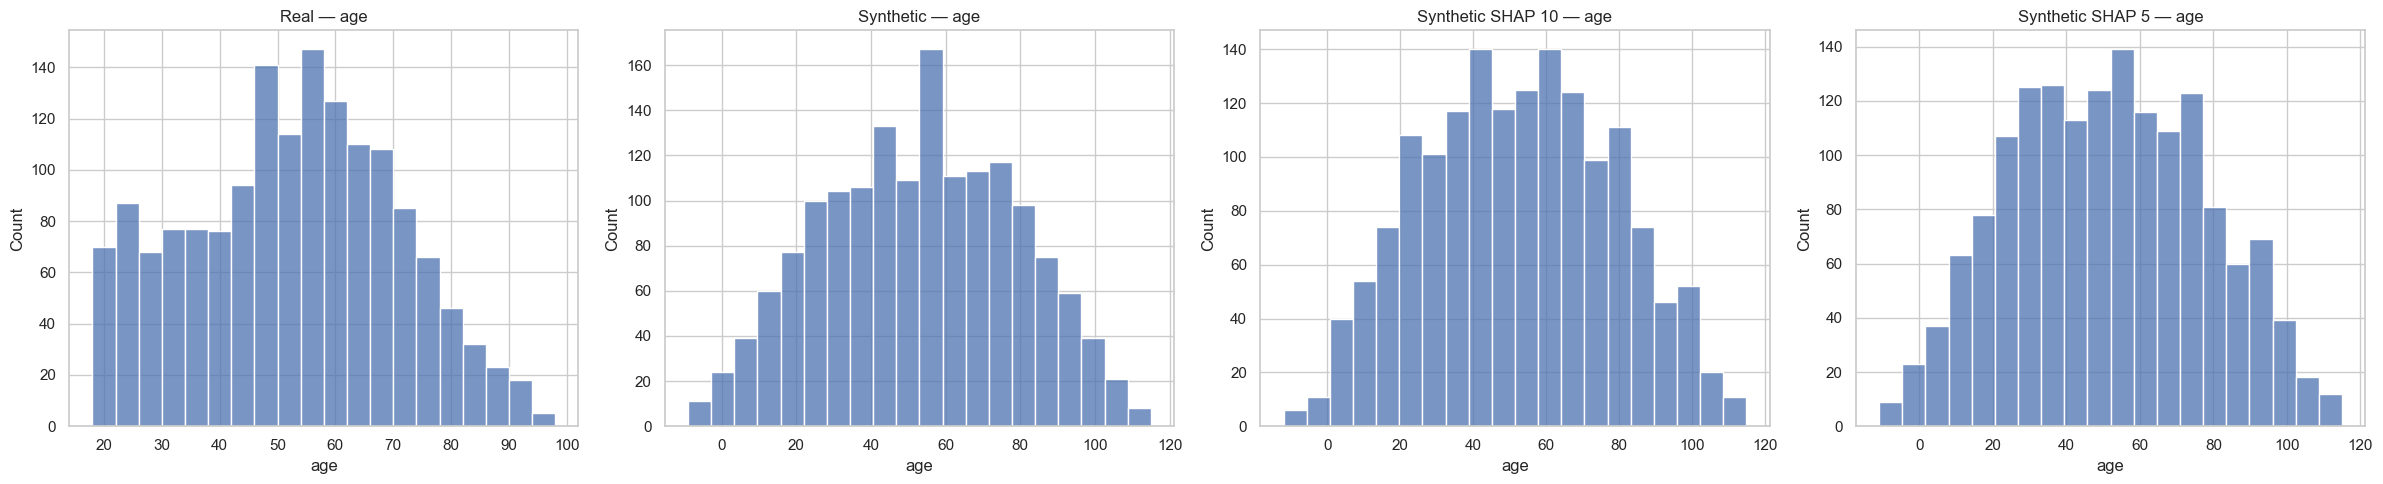

In [44]:
compare_histograms(df_list, names, column="age", bins=20)

### Distribution of the weight

Outlier the weight?

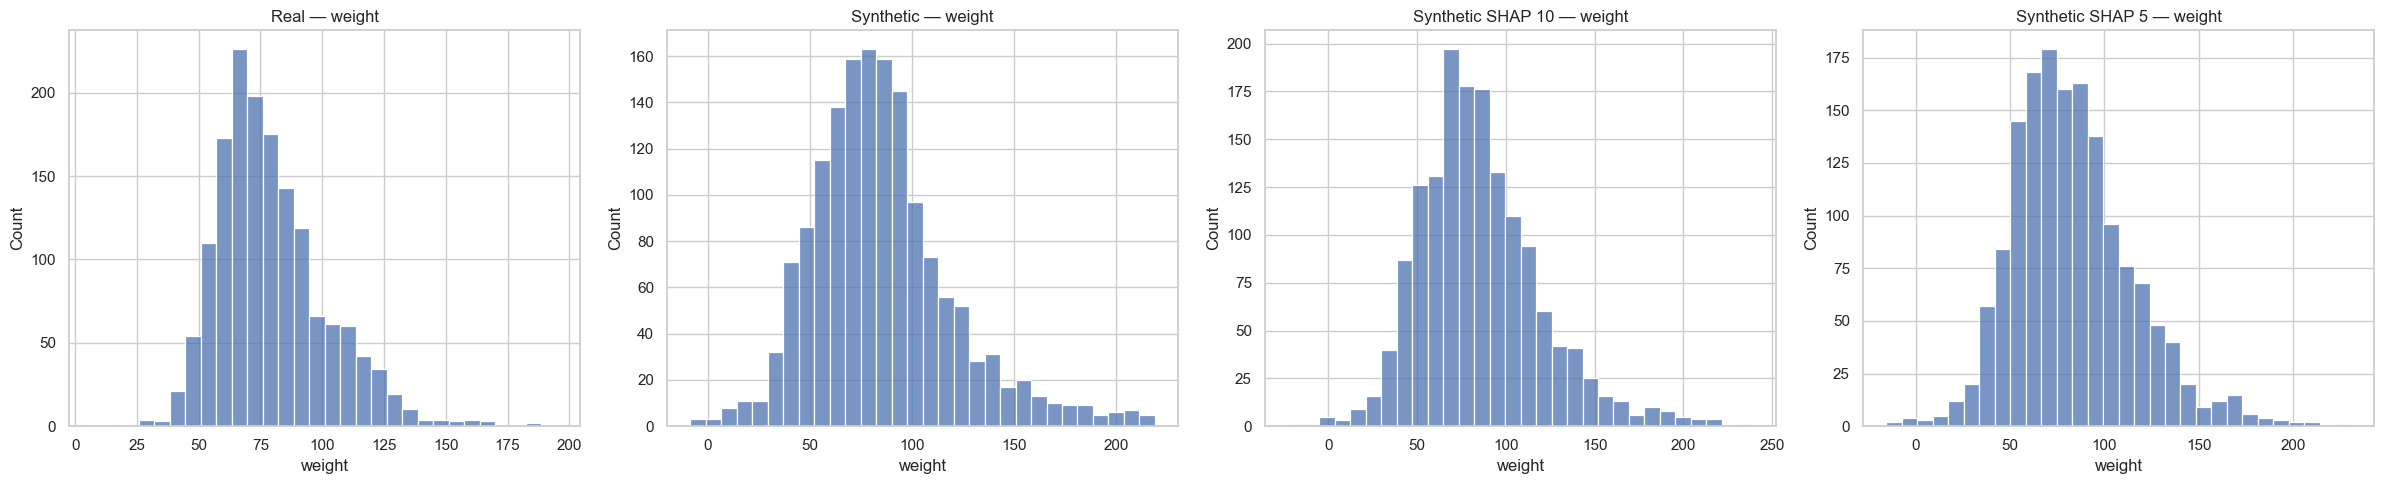

In [45]:
compare_histograms(df_list, names, column="weight", bins=30)

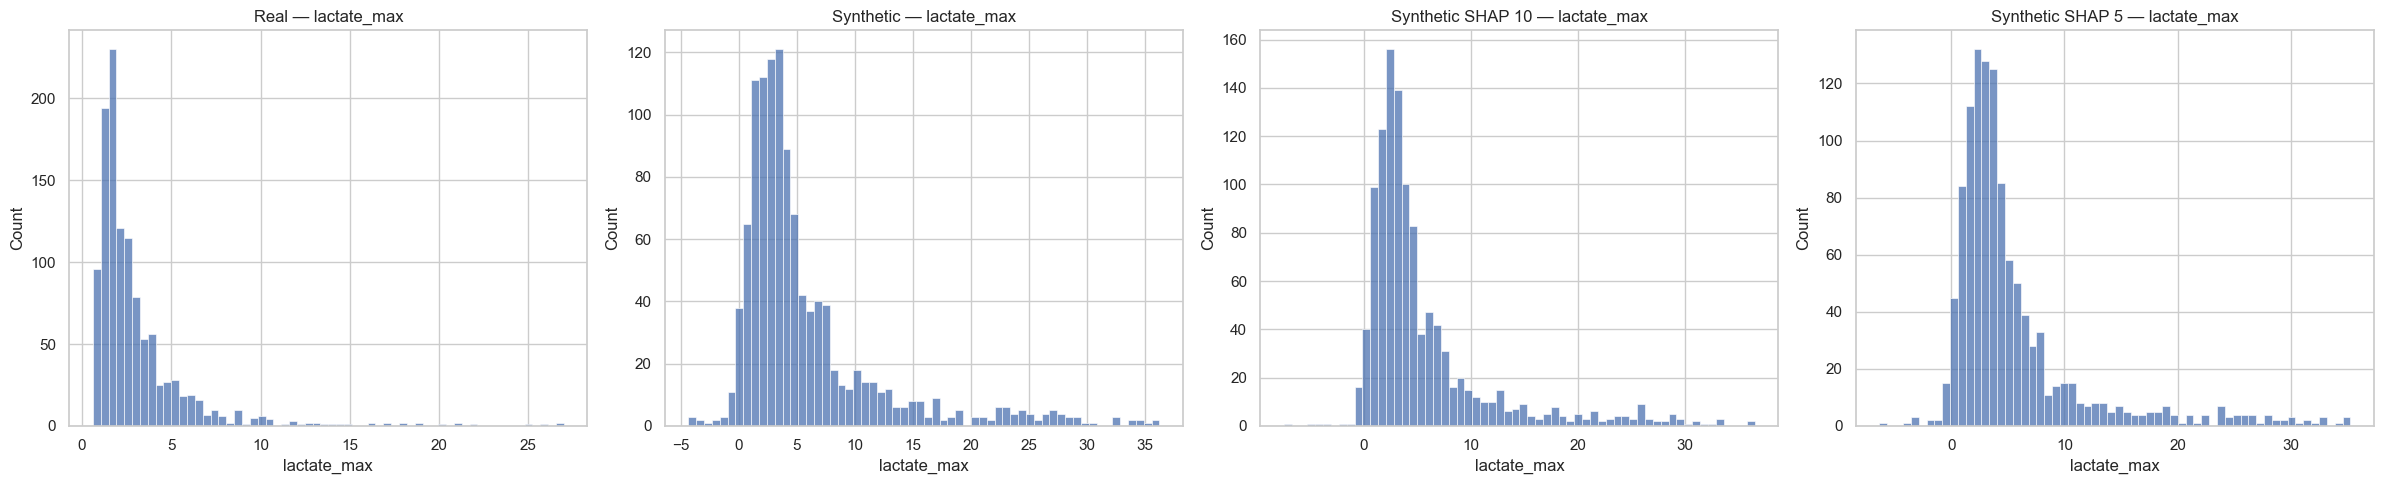

In [46]:
compare_histograms(df_list, names, column="lactate_max", bins=60)

## Categorical - Race

In [ ]:
def get_cat_counts(df, colname, label):
    # vc = df[colname].value_counts(dropna=False) # If I want counts instead of proportions
    vc = df[colname].value_counts(normalize=True, dropna=False)
    return (
        vc.rename("count")
          .reset_index()
          .rename(columns={"index": colname})
          .assign(dataset=label)
    )

feature_name = "race"
df_real  = get_cat_counts(real_shap_30, feature_name, "real")
df_syn   = get_cat_counts(syn_data, feature_name, "synthetic")
df_syn_s = get_cat_counts(syn_data_10, feature_name, "synthetic_shap")

all_counts = pd.concat([df_real, df_syn, df_syn_s], ignore_index=True)

pivot = all_counts.pivot(index=feature_name, columns="dataset", values="count").fillna(0)
pivot = pivot.sort_values(feature_name, ascending=True)

plt.figure(figsize=(12, 10))
pivot.plot(kind="barh", figsize=(12, 10))

plt.xlabel("Proportion") # "Count" to "Proportion"
plt.ylabel(f"{feature_name}")
plt.title(f"{feature_name} distribution: Real vs Synthetic vs SHAP-Synthetic")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()



KeyError: 'gender'

In [29]:
def get_categorical_vars_value(df, categorical_vars):
    for col in categorical_vars:
        if col in df.columns:
            print(f"\n{col}:\n", df[col].value_counts(dropna=False))


In [30]:
categorical_vars = ['race']
get_categorical_vars_value(real_shap_30, categorical_vars)
get_categorical_vars_value(syn_data_baseline, categorical_vars)
get_categorical_vars_value(syn_data_shap, categorical_vars)



race:
 race
WHITE                                        829
BLACK/AFRICAN AMERICAN                       344
UNKNOWN                                       81
OTHER                                         59
WHITE - OTHER EUROPEAN                        39
HISPANIC/LATINO - PUERTO RICAN                32
HISPANIC OR LATINO                            28
UNABLE TO OBTAIN                              21
BLACK/CARIBBEAN ISLAND                        18
ASIAN - CHINESE                               17
ASIAN                                         14
BLACK/CAPE VERDEAN                            13
HISPANIC/LATINO - DOMINICAN                   12
BLACK/AFRICAN                                 12
WHITE - RUSSIAN                                8
PORTUGUESE                                     6
HISPANIC/LATINO - SALVADORAN                   5
HISPANIC/LATINO - CENTRAL AMERICAN             5
ASIAN - SOUTH EAST ASIAN                       4
WHITE - EASTERN EUROPEAN                       4
HISPANI

### Binary distribution

In [50]:
def compare_categorical_distributions(df_list, names, column):
    """
    Plot one figure with multi-dataset categorical distributions.
    Each category gets a grouped bar (one bar per dataset).
    """

    # Build tidy dataframe with counts
    frames = []
    for df, name in zip(df_list, names):
        vc = df[column].value_counts(dropna=False, normalize=False)
        temp = pd.DataFrame({
            column: vc.index.astype(str),
            "count": vc.values,
            "dataset": name
        })
        frames.append(temp)

    data = pd.concat(frames, ignore_index=True)

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=data,
        x=column,
        y="count",
        hue="dataset"
    )

    plt.title(f"{column} Distribution Comparison", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Deads
 In hospital death

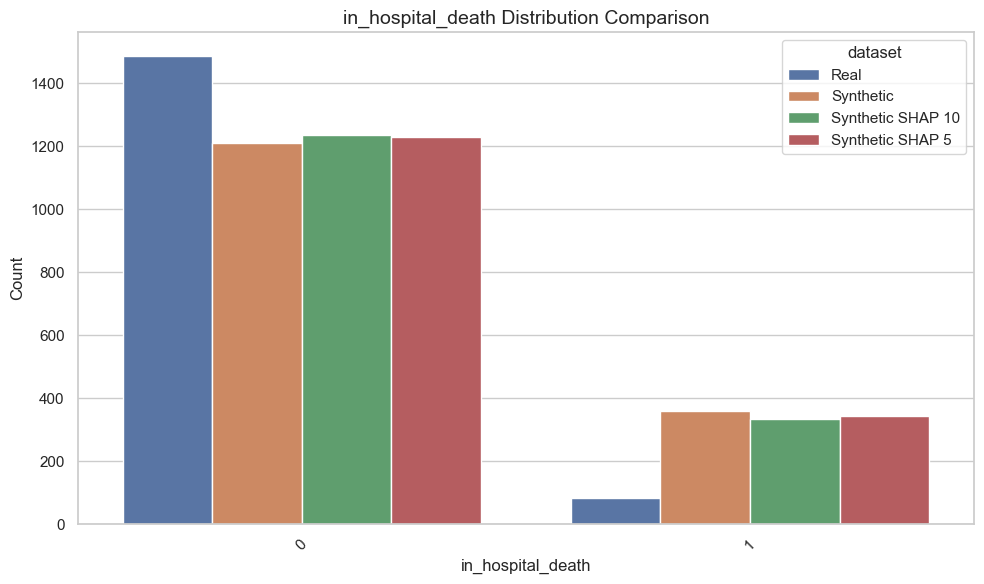

In [51]:

compare_categorical_distributions(df_list, names, column="in_hospital_death")

### Gender

### Insurance

### Emegency


### Laboratory test   TODO

In [ ]:
lab_features = [
    'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'osmolality_initial'
]

for feature in lab_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=real_shap_30, x='in_hospital_death', y=feature)
    plt.title(f'{feature} by Death Outcome')
    plt.show()




In [ ]:
comorbidities = [
    'aki', 'ckd', 'diabetes_with_cc',
    'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd'
]

comorbidity_counts = real_shap_30.groupby('in_hospital_death')[comorbidities].sum().T
comorbidity_counts.columns = ['Survived', 'Died']
comorbidity_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Comorbidities by Death Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Characteristic at baseline between survivors and non-survivors group

In [ ]:
!pip install tableone
!pip install --upgrade statsmodels

In [1]:
import sys
!{sys.executable} -m pip install scipy
!pip install pandas==2.1.4


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.2
    Uninstalling pandas-2.0.2:
      Successfully uninstalled pandas-2.0.2

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [94]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest, kurtosistest
from tableone import TableOne

In [3]:
def get_nonnormal_columns(df, alpha=0.05):
    # Agostino and Anscombe tests
    # D’Agostino and Pearson Normality Test
    non_normal_cols = []
    for col in df.columns:
        data = df[col].dropna()
        if len(data) < 8:
            continue

        stat_nt, p_nt = normaltest(data)
        stat_kg, p_kg = kurtosistest(data)
        if p_nt < alpha or p_kg < alpha:
            non_normal_cols.append(col)
    return non_normal_cols

In [4]:
# Load your dataset
data = pd.read_csv('icu_dka_dataset_20250723.csv')

# Define labels and columns
column_labels = {
    'age': 'Age (year)',
    'gender': 'Male (%)',
    'race': 'White (%)',
    'heart_rate_initial': 'Heartrate (bpm)',
    'heart_rate_max': 'Heartrate_max (bpm)',
    'mbp_initial': 'MAP (mmHg)',
    'mbp_min': 'MAP_min (mmHg)',
    'resp_rate_initial': 'Respiratory_rate (insp/min)',
    'resp_rate_max': 'Respiratoryrate_max (insp/min)',
    'urineoutput': 'Urineoutput (ml)',
    'apsiii': 'APS III score',
    'sofa': 'SOFA score',
    'gcs': 'GCS score',
    'cns': 'CNS score',
    'renal': 'Renal score',
    'weight': 'Weight (kg)',
    'emergency': 'Admission, emergency (%)',
    'ventilation': 'Ventilation (%)',
    'nitroprusside': 'Nitrate pune (%)',
    'vasopressor': 'Vasopressor (%)',
    'albumin': 'Albumin (%)',
    'aki': 'AKI (%)',
    'ckd': 'CKD (%)',
    'cardiac_disease': 'Cardiac disease (%)',
    'hypertension': 'Hypertension (%)',
    'copd': 'COPD (%)',
    'lactate_max': 'Lactate_max (mmol/L)',
    'creatinine_initial': 'Scr (mg/dL)',
    'creatinine_max': 'Scr_max (mg/dL)',
    'ph_initial': 'PH',
    'ph_min': 'PH_min',
    'glucose_initial': 'Glucose (mg/dL)',
    'glucose_max': 'Glucose_max (mg/dL)',
    'sodium_initial': 'Sodium (mEq/L)',
    'sodium_max': 'Sodium_max (mEq/L)',
    'potassium_initial': 'Potassium (mEq/L)',
    'potassium_max': 'Potassium_max (mEq/L)',
    'calcium_initial': 'Calcium (mg/dL)',
    'chloride_initial': 'Chloride (mEq/L)',
    'wbc_initial': 'WBC (K/uL)',
    'wbc_max': 'WBC_max (K/uL)',
    'platelet_initial': 'PLT (K/uL)',
    'platelet_min': 'PLT_min (K/uL)',
    'bun_max': 'BUN_max (mg/dL)',
    'osmolality_initial': 'osmolarity',
    'osmolality_max': 'osmolarity_max',
    'osmolality_min': 'osmolarity_min'
}

columns = list(column_labels.keys())

categorical = [
    'gender', 'race', 'emergency', 'ventilation', 'nitroprusside', 'vasopressor',
    'albumin', 'aki', 'ckd', 'cardiac_disease', 'hypertension', 'copd'
]
continuous = [col for col in columns if col not in categorical]


labels = {var: {1: column_labels[var]} for var in categorical}
# print(labels)

# Custom labels
survivors_n = len(data[data['in_hospital_death'] == 0])
nonsurvivors_n = len(data[data['in_hospital_death'] == 1])
data['in_hospital_death_label'] = data['in_hospital_death'].map({
    1: f'Nonsurvivors (n={nonsurvivors_n})',
    0: f'Survivors (n={survivors_n})'
})

limit={
    'gender':1,
    'race':1
}

nonnormal = get_nonnormal_columns(data[continuous])
# Remove age to simulate the paper table
nonnormal.remove('age')

# Create TableOne
table = TableOne(
    data,
    columns=columns,
    categorical=categorical,
    labels=labels,
    groupby='in_hospital_death_label',
    pval=True,
    rename=column_labels,
    label_suffix=False,
    missing=False,
    limit=limit,
    decimals=2,
    nonnormal=nonnormal
)

# Print TableOne
print(table.tabulate(tablefmt="github"))


|                                |       | Overall                   | Nonsurvivors (n=83)     | Survivors (n=1488)        | P-Value   |
|--------------------------------|-------|---------------------------|-------------------------|---------------------------|-----------|
| n                              |       | 1571                      | 83                      | 1488                      |           |
| Age (year)                     |       | 51.94 (17.97)             | 65.59 (15.56)           | 51.18 (17.80)             | <0.001    |
| Male (%)                       | M     | 827 (52.64)               | 44 (53.01)              | 783 (52.62)               | 1.000     |
| White (%)                      | WHITE | 829 (52.77)               | 30 (36.14)              | 799 (53.70)               | <0.001    |
| Heartrate (bpm)                |       | 97.00 [85.00,109.00]      | 95.00 [81.50,108.50]    | 97.00 [85.00,109.00]      | 0.602     |
| Heartrate_max (bpm)            |       

In [62]:
table.to_csv('table.csv')

In [5]:
table.tabulate(tablefmt="latex")

'\\begin{tabular}{llllll}\n\\hline\n                                &       & Overall                   & Nonsurvivors (n=83)     & Survivors (n=1488)        & P-Value   \\\\\n\\hline\n n                              &       & 1571                      & 83                      & 1488                      &           \\\\\n Age (year)                     &       & 51.94 (17.97)             & 65.59 (15.56)           & 51.18 (17.80)             & \\ensuremath{<}0.001    \\\\\n Male (\\%)                       & M     & 827 (52.64)               & 44 (53.01)              & 783 (52.62)               & 1.000     \\\\\n White (\\%)                      & WHITE & 829 (52.77)               & 30 (36.14)              & 799 (53.70)               & \\ensuremath{<}0.001    \\\\\n Heartrate (bpm)                &       & 97.00 [85.00,109.00]      & 95.00 [81.50,108.50]    & 97.00 [85.00,109.00]      & 0.602     \\\\\n Heartrate\\_max (bpm)            &       & 106.00 [95.25,119.00]     & 111.00 [98.